# Inflation Project — Comparison Across All Five Potentials

Overlays every graph type (background, perturbation, spectra) across quadratic, quartic, hilltop, Starobinsky, and natural inflation, all at the shared $N_{\rm end}=65$, $N_*=50$, `Nic_cond=100` benchmark established in the individual notebooks.

In [1]:
import numpy as np
from scipy import integrate
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

## Core framework (same as in the individual notebooks)

In [2]:
def background_eqn(N, fields, potential):
    phi, dphidN = fields
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN \
               - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    return [dphidN, d2phidN2]

def Hubble(phi_N, V):
    return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))

def epsilon1(phi_N):
    return 0.5*phi_N*phi_N

def stop_integration(N, y):
    return 0.5*(y[1]**2) - 1
stop_integration.terminal = True
stop_integration.direction = 0

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def z_of(a, phi_N):
    return a*phi_N

def solve_background(potential, ph_initial, t_end=250.0, fine_step=1e-4):
    efolds_fine = np.arange(0, t_end, fine_step)
    sol = solve_ivp(lambda N, y: background_eqn(N, y, potential),
                     [0, t_end], ph_initial, method='RK45',
                     dense_output=True, events=(stop_integration,), max_step=np.inf)
    Nend = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else sol.t[-1]
    mask = efolds_fine < Nend
    efolds = efolds_fine[mask]
    y = sol.sol(efolds)
    phi, dphi = y[0], y[1]
    pot, dpotdphi = potential(phi)
    Hub = Hubble(dphi, pot)
    return dict(efolds=efolds, phi=phi, dphi=dphi, pot=pot,
                dpotdphi=dpotdphi, Hub=Hub, Nend=Nend)

def pert_eqn(y, N, k, ai, potential):
    phi, dphidN, Rk_re, Rk_re_N, Rk_im, Rk_im_N, hk_re, hk_re_N, hk_im, hk_im_N = y
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    a = ai*np.exp(N)
    H = np.sqrt(v/(3 - 0.5*(dphidN*dphidN)))
    zN = a*(dphidN + d2phidN2)
    zval = z_of(a, dphidN)
    Rk_re_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_re_N - ((k/(a*H))**2)*Rk_re
    Rk_im_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_im_N - ((k/(a*H))**2)*Rk_im
    hk_re_NN = -(3 - (dphidN**2)*0.5)*hk_re_N - ((k/(a*H))**2)*hk_re
    hk_im_NN = -(3 - (dphidN**2)*0.5)*hk_im_N - ((k/(a*H))**2)*hk_im
    return [dphidN, d2phidN2, Rk_re_N, Rk_re_NN, Rk_im_N, Rk_im_NN,
            hk_re_N, hk_re_NN, hk_im_N, hk_im_NN]

def boundary(k, t, aH, Nic_cond, Nshs_cond):
    ic_diff = k - Nic_cond*aH
    shs_diff = k - Nshs_cond*aH
    idx_ic, _ = find_nearest(ic_diff, 0)
    idx_shs, _ = find_nearest(shs_diff, 0)
    return idx_ic, t[idx_ic], t[idx_shs]

def initial_condition(idx_ic, k, efolds, phi, dphi, ai, Hub, potential):
    phi_ic = phi[idx_ic]; phiN_ic = dphi[idx_ic]
    a_ic = ai*np.exp(efolds[idx_ic]); z_ic = z_of(a_ic, phiN_ic); H_ic = Hub[idx_ic]
    _, phiNN_ic = background_eqn(efolds[idx_ic], [phi_ic, phiN_ic], potential)
    Rk_re_ic = (1/(np.sqrt(2*k)))/z_ic
    Rk_im_ic = 0
    Rk_re_N_ic = -Rk_re_ic*((phiNN_ic/phiN_ic) + 1)
    Rk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*z_ic)
    hk_re_ic = (1/(np.sqrt(2*k)))/a_ic
    hk_im_ic = 0
    hk_re_N_ic = -hk_re_ic
    hk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*a_ic)
    return [phi_ic, phiN_ic, Rk_re_ic, Rk_re_N_ic, Rk_im_ic, Rk_im_N_ic,
            hk_re_ic, hk_re_N_ic, hk_im_ic, hk_im_N_ic]

def Psk(kk, Rk):
    Rk_re, Rk_im = Rk
    return kk**3/(2e0*np.pi**2)*((Rk_re*Rk_re)+(Rk_im*Rk_im))

def Pth(kk, hk):
    hk_re, hk_im = hk
    return 8.0*kk**3/(2e0*np.pi**2)*((hk_re*hk_re)+(hk_im*hk_im))

class InflationRun:
    def __init__(self, potential, bg, kpivot=0.05, Nic_cond=100, Nshs_cond=1e-5):
        self.potential = potential
        self.efolds = bg['efolds']; self.phi = bg['phi']; self.dphi = bg['dphi']
        self.Hub = bg['Hub']; self.Nend = bg['Nend']
        self.Nic_cond = Nic_cond; self.Nshs_cond = Nshs_cond
        idx50, Ne50 = find_nearest(self.efolds, self.Nend - 50)
        self.idx50, self.Ne50 = idx50, Ne50
        self.ai = kpivot/(np.exp(Ne50)*self.Hub[idx50])
        self.kpivot = kpivot

    def compute_pps(self, kk, atol=1e-13):
        idx_ic, Nic, Nshs = boundary(kk, self.efolds, self.ai*np.exp(self.efolds)*self.Hub,
                                      self.Nic_cond, self.Nshs_cond)
        efolds_pert = np.arange(Nic, Nshs, 0.01)
        pert_ic = initial_condition(idx_ic, kk, self.efolds, self.phi, self.dphi,
                                     self.ai, self.Hub, self.potential)
        sol_pert = integrate.odeint(pert_eqn, pert_ic, efolds_pert,
                                     args=(kk, self.ai, self.potential), atol=atol)
        Rkshs = [sol_pert[-1,2], sol_pert[-1,4]]
        hkshs = [sol_pert[-1,6], sol_pert[-1,8]]
        return Psk(kk, Rkshs), Pth(kk, hkshs), efolds_pert, sol_pert, Nic, Nshs

    def spectrum(self, karray, atol=1e-13):
        PS = np.zeros(len(karray)); PT = np.zeros(len(karray))
        for i, kk in enumerate(karray):
            PS[i], PT[i], _, _, _, _ = self.compute_pps(kk, atol=atol)
        return PS, PT

## The five potentials, with their final tuned parameters ($N_{\rm end}=65$, pivot amplitude $2.05\times10^{-9}$)

In [3]:
def quad_potential(phi, mass=6.973254e-06):
    v = 0.5*mass**2*phi*phi; dv = mass**2*phi
    return v, dv

def quartic_potential(phi, lam=2.387385e-13):
    v = 0.25*lam*phi**4; dv = lam*phi**3
    return v, dv

def hilltop_potential(phi, V0=1.695819e-11, mu=5.5):
    v = V0*(1-(phi/mu)**2); dv = -V0*2*phi/mu**2
    return v, dv

def star_potential(phi, V0=1.328758e-10, q=np.sqrt(2/3)):
    u = np.exp(-q*phi)
    v = V0*(1-u)**2; dv = 2*q*V0*u*(1-u)
    return v, dv

def nat_potential(phi, Lam4=8.688603e-10, f=5.0):
    v = Lam4*(1-np.cos(phi/f)); dv = Lam4*np.sin(phi/f)/f
    return v, dv

def symbreak_potential(phi, V0=8.983374e-12, mu=7.0):
    x = phi/mu
    v = V0*(1-x**2)**2
    dv = V0*2*(1-x**2)*(-2*x/mu)
    return v, dv

def mix_potential(phi, scale=2.916212e-12, g=0.1):
    v = scale*(0.5*phi**2 + (g/4.0)*phi**4)
    dv = scale*(phi + g*phi**3)
    return v, dv

def tmodel_potential(phi, V0=7.242734e-10, alpha=5.0, n=1.0):
    lam = 1.0/np.sqrt(6*alpha)
    x = lam*phi
    t = np.tanh(x)
    v = V0*t**(2*n)
    dv = V0*2*n*t**(2*n-1)*(1-t**2)*lam
    return v, dv

POTENTIALS = {
    'quadratic':   dict(fn=quad_potential,    phi_i=16.054755, color='C0'),
    'quartic':     dict(fn=quartic_potential, phi_i=22.795671, color='C1'),
    'hilltop':     dict(fn=hilltop_potential, phi_i=0.051302,  color='C2'),
    'starobinsky': dict(fn=star_potential,    phi_i=5.517953,  color='C3'),
    'natural':     dict(fn=nat_potential,     phi_i=12.901140, color='C4'),
    'symbreak':    dict(fn=symbreak_potential, phi_i=0.024637, color='C5'),
    'quad+quartic mix': dict(fn=mix_potential, phi_i=21.861617, color='C6'),
    'T-model':     dict(fn=tmodel_potential,  phi_i=9.824549, color='C7'),
}

## Solve the background + build the `InflationRun` for each potential

In [4]:
runs = {}
for name, cfg in POTENTIALS.items():
    pot = cfg['fn']
    ph_initial = [cfg['phi_i'], None]
    Vini, dVini = pot(cfg['phi_i'])
    ph_initial[1] = -dVini/Vini
    bg = solve_background(pot, ph_initial, t_end=250, fine_step=1e-4)
    run = InflationRun(pot, bg, kpivot=0.05, Nic_cond=100)
    runs[name] = dict(bg=bg, run=run)
    print(f'{name:<12} N_end={bg["Nend"]:.4f}')

quadratic    N_end=65.0000


quartic      N_end=65.0000


hilltop      N_end=65.0001


starobinsky  N_end=65.0000


natural      N_end=65.0000


symbreak     N_end=65.0000


quad+quartic mix N_end=65.0000


T-model      N_end=65.0000


## Plot 1 — $\phi(N)$ overlay

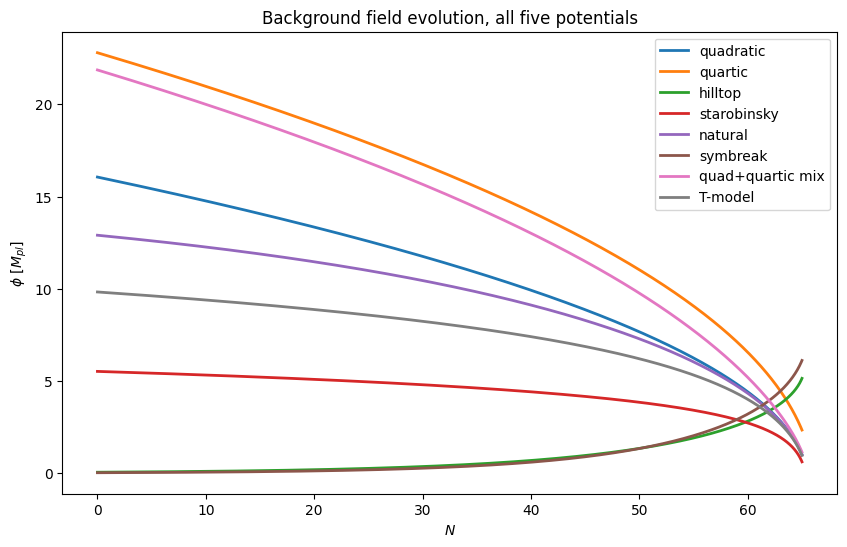

In [5]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    bg = runs[name]['bg']
    plt.plot(bg['efolds'], bg['phi'], label=name, color=cfg['color'], lw=2)
plt.xlabel('$N$'); plt.ylabel(r'$\phi\ [M_{pl}]$')
plt.title('Background field evolution, all five potentials')
plt.legend(); plt.show()

## Plot 2 — $d\phi/dN$ overlay

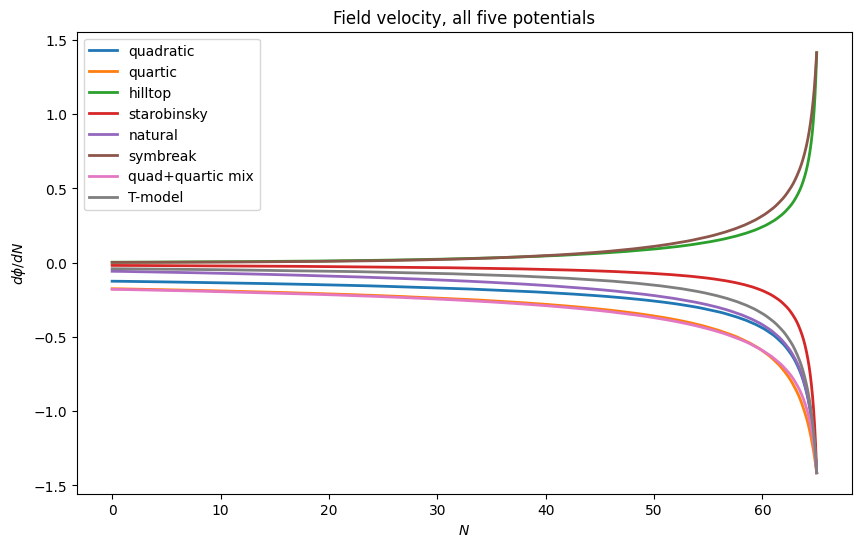

In [6]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    bg = runs[name]['bg']
    plt.plot(bg['efolds'], bg['dphi'], label=name, color=cfg['color'], lw=2)
plt.xlabel('$N$'); plt.ylabel(r'$d\phi/dN$')
plt.title('Field velocity, all five potentials')
plt.legend(); plt.show()

## Plot 3 — $\varepsilon_1(N)$ overlay (aligned at end of inflation)

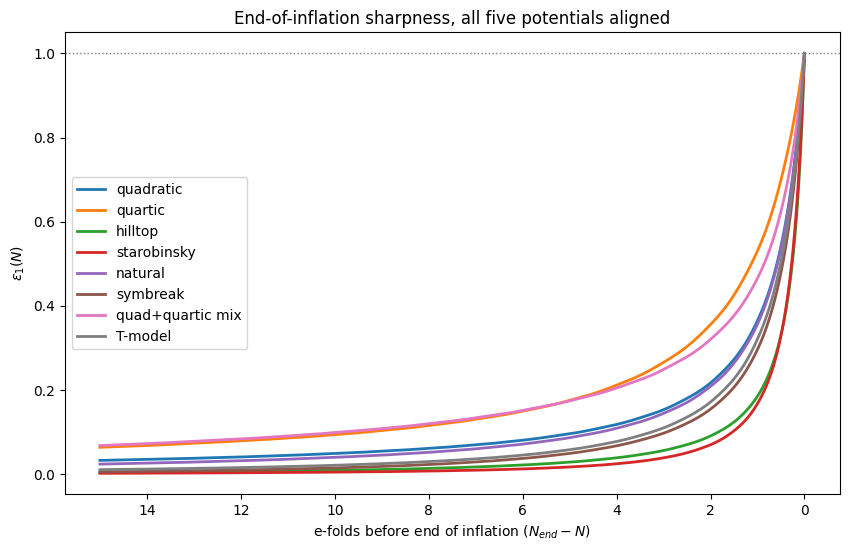

In [7]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    bg = runs[name]['bg']
    eps1 = epsilon1(bg['dphi'])
    N_before_end = bg['Nend'] - bg['efolds']
    mask = N_before_end < 15
    plt.plot(N_before_end[mask], eps1[mask], label=name, color=cfg['color'], lw=2)
plt.gca().invert_xaxis()
plt.xlabel('e-folds before end of inflation ($N_{end}-N$)')
plt.ylabel(r'$\varepsilon_1(N)$')
plt.title('End-of-inflation sharpness, all five potentials aligned')
plt.axhline(1.0, ls=':', color='gray', lw=1)
plt.legend(); plt.show()

## Pivot-mode perturbation solve (needed for the $\mathcal{R}_k$ plots)

In [8]:
for name in POTENTIALS:
    run = runs[name]['run']
    pps_piv, ppt_piv, efolds_pert, sol_pert, Nic, Nshs = run.compute_pps(0.05)
    runs[name]['pivot'] = dict(pps=pps_piv, ppt=ppt_piv, efolds_pert=efolds_pert,
                                sol_pert=sol_pert, Nic=Nic, Nshs=Nshs)
    print(f'{name:<12} r={ppt_piv/pps_piv:.6f}')

quadratic    r=0.158226
quartic      r=0.313206
hilltop      r=0.000558
starobinsky  r=0.004255
natural      r=0.049256
symbreak     r=0.000296
quad+quartic mix r=0.328861


T-model      r=0.020701


## Plot 4 — $\mathcal{R}_k(N)$ overlay (pivot mode, real part)

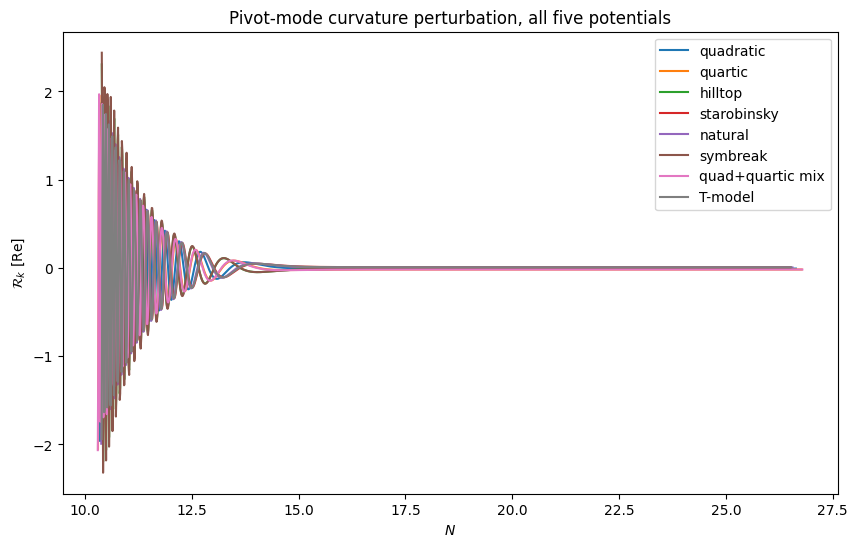

In [9]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    p = runs[name]['pivot']
    plt.plot(p['efolds_pert'], p['sol_pert'][:,2], label=name, color=cfg['color'], lw=1.5)
plt.xlabel('$N$'); plt.ylabel(r'$\mathcal{R}_k$ [Re]')
plt.title('Pivot-mode curvature perturbation, all five potentials')
plt.legend(); plt.show()

## Plot 5 — $d\mathcal{R}_k/dN$ overlay (pivot mode, real part)

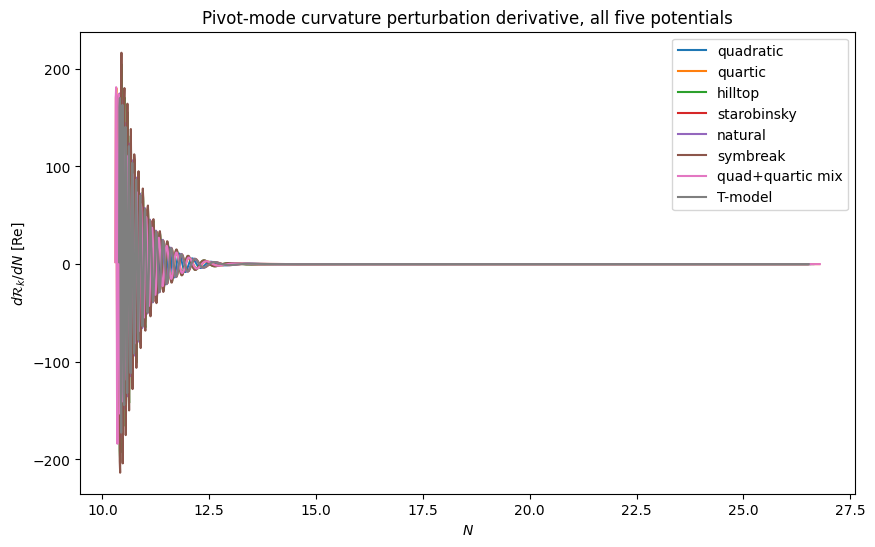

In [10]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    p = runs[name]['pivot']
    plt.plot(p['efolds_pert'], p['sol_pert'][:,3], label=name, color=cfg['color'], lw=1.5)
plt.xlabel('$N$'); plt.ylabel(r'$d\mathcal{R}_k/dN$ [Re]')
plt.title('Pivot-mode curvature perturbation derivative, all five potentials')
plt.legend(); plt.show()

## Full spectra across $k$, for all five (this cell takes a little while)

In [11]:
karray = np.logspace(-4, 0, 200)
for name in POTENTIALS:
    run = runs[name]['run']
    PS, PT = run.spectrum(karray)
    runs[name]['PS'] = PS
    runs[name]['PT'] = PT
    print(f'{name:<12} done')

quadratic    done


quartic      done


hilltop      done


starobinsky  done


natural      done


symbreak     done


quad+quartic mix done


T-model      done


## Plot 6 — $\mathcal{P}_\mathcal{R}(k)$ overlay

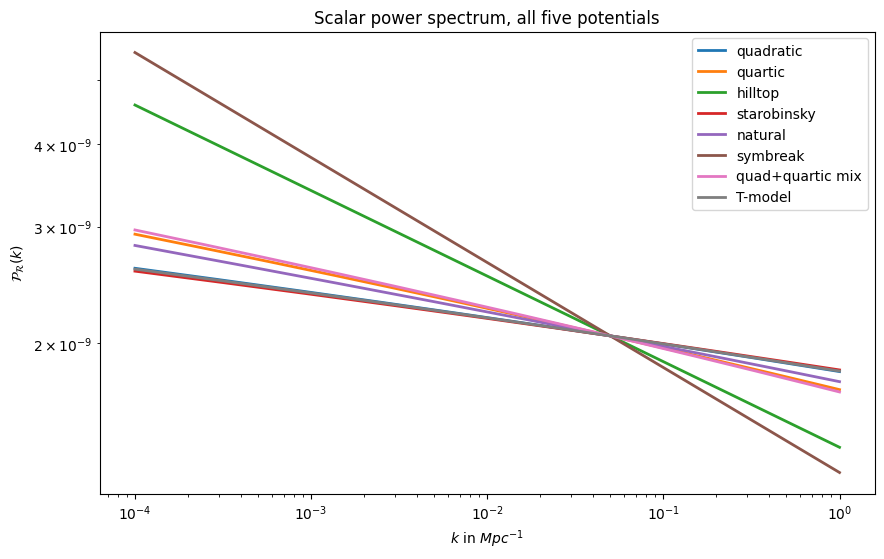

In [12]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    plt.plot(karray, runs[name]['PS'], label=name, color=cfg['color'], lw=2)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('$k$ in $Mpc^{-1}$'); plt.ylabel(r'$\mathcal{P}_\mathcal{R}(k)$')
plt.title('Scalar power spectrum, all five potentials')
plt.legend(); plt.show()

## Plot 7 — $\mathcal{P}_h(k)$ overlay

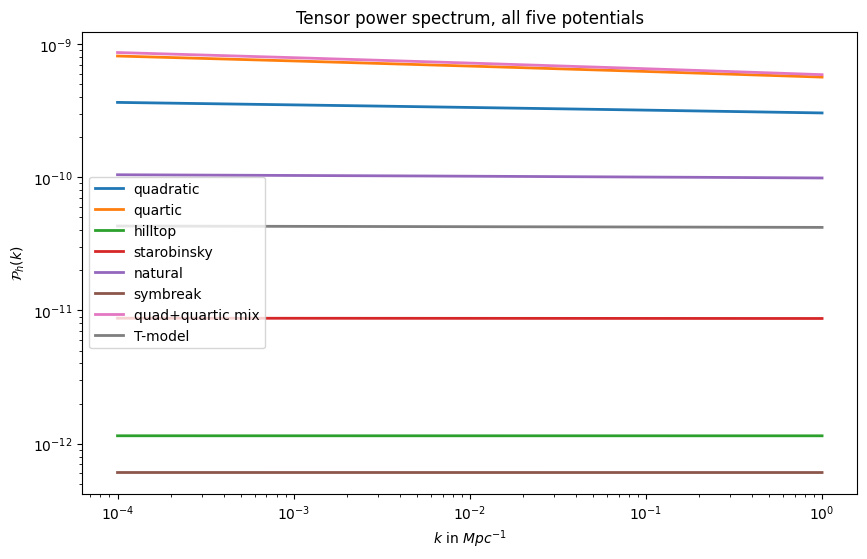

In [13]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    plt.plot(karray, runs[name]['PT'], label=name, color=cfg['color'], lw=2)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('$k$ in $Mpc^{-1}$'); plt.ylabel(r'$\mathcal{P}_h(k)$')
plt.title('Tensor power spectrum, all five potentials')
plt.legend(); plt.show()

## Plot 8 — $r(k)$ overlay

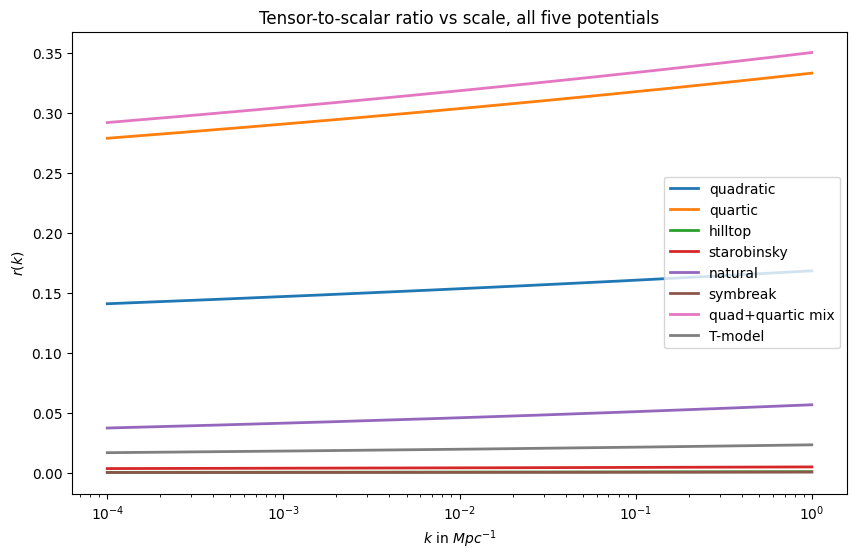

In [14]:
plt.figure(figsize=(10,6))
for name, cfg in POTENTIALS.items():
    r_of_k = runs[name]['PT']/runs[name]['PS']
    plt.plot(karray, r_of_k, label=name, color=cfg['color'], lw=2)
plt.xscale('log')
plt.xlabel('$k$ in $Mpc^{-1}$'); plt.ylabel(r'$r(k)$')
plt.title('Tensor-to-scalar ratio vs scale, all five potentials')
plt.legend(); plt.show()